In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV,cross_validate
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df=pd.read_csv(r"C:\Users\ASUS\Desktop\heart.csv")

In [3]:
df.head(3)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(302, 14)

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [10]:
df.dtypes

age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
output        int64
dtype: object

In [11]:
df=pd.get_dummies(df,columns=["restecg"],dtype=int)

In [12]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'thalachh', 'exng',
       'oldpeak', 'slp', 'caa', 'thall', 'output', 'restecg_0', 'restecg_1',
       'restecg_2'],
      dtype='object')

In [13]:
feature=['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'thalachh', 'exng',
       'oldpeak', 'slp', 'caa', 'thall', 'output', 'restecg_0', 'restecg_1',
       'restecg_2']

In [14]:
x=df.drop("output",axis=1)
y=df["output"]

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [17]:
dtree=DecisionTreeClassifier(criterion="entropy",max_depth=4,random_state=42)
dtree.fit(x_train,y_train)

y_pred_tree=dtree.predict(x_test)

In [18]:
print(confusion_matrix(y_test,y_pred_tree))

[[28 14]
 [ 2 47]]


In [19]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78        42
           1       0.77      0.96      0.85        49

    accuracy                           0.82        91
   macro avg       0.85      0.81      0.82        91
weighted avg       0.85      0.82      0.82        91



In [20]:
accuracy_score(y_test,y_pred_tree)

0.8241758241758241

In [21]:
from sklearn.tree import plot_tree

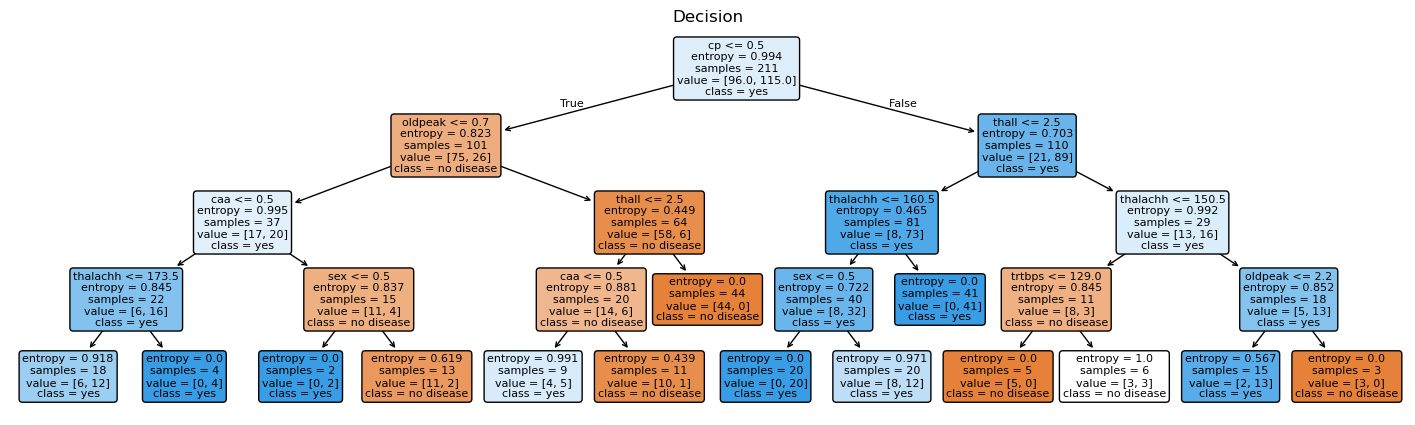

In [22]:
plt.figure(figsize=[18,5])
plot_tree(dtree,feature_names=x.columns,class_names=["no disease","yes"],filled=True,rounded=True,fontsize=8)
plt.savefig("01.png",dpi=100,bbox_inches="tight")
plt.title("Decision")
plt.show()